In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import re

In [3]:
# Load the approx algorithms dataset
columns = [
    'Family Name', 
    'Variation',
    'Algorithm Name', 
    'Year',
    'Looked at?',
    'Use For Inapprox?',
    'Parallel?',
    'Time Complexity Class',
    'Approximation Factor (if approximate algorithm)',
    'Approximation Factor Class (Mult)', 
    'Approximation Factor Class (Add)',
    'Approximation Type (additive/multiplicative)',	
    'Parametrized Approximation?',
    'Type of PTAS (if PTAS)',
    'Quantum?'
]
approximation_algorithms = pd.read_csv('approx_algos.csv', usecols=columns)

# Clean and prepare the data
# drop Looked at? == 0.001 or 0
approximation_algorithms = approximation_algorithms[approximation_algorithms['Looked at?'] != '0.001']
approximation_algorithms = approximation_algorithms[approximation_algorithms['Looked at?'] != '0']
# drop Relevant? == 0
approximation_algorithms = approximation_algorithms[approximation_algorithms['Use For Inapprox?'] != 0]
approximation_algorithms = approximation_algorithms[approximation_algorithms['Use For Inapprox?'] != '0']

# filter out parallel algorithms
approximation_algorithms = approximation_algorithms[approximation_algorithms['Parallel?'] != '1']

approximation_algorithms = approximation_algorithms[approximation_algorithms['Quantum?'] != '1']
approximation_algorithms = approximation_algorithms[approximation_algorithms['Quantum?'] != 1]

# separate entries with >1 variants into multiple entries
for idx, row in approximation_algorithms.iterrows():
    variations = row['Variation']
    if ';' not in variations:
        continue
    approximation_algorithms = approximation_algorithms.drop(index=idx)
    variation_sep = [s.strip() for s in variations.split(';')]
    for variation in variation_sep:
        series = row.copy()
        series['Variation'] = variation
        frame = series.to_frame().T
        approximation_algorithms = pd.concat([approximation_algorithms, frame], ignore_index=True)
    


approximation_algorithms['Year'] = pd.to_numeric(approximation_algorithms['Year'].str.extract(r'(\d{4})')[0], errors='coerce')
approximation_algorithms.dropna(subset=['Year'], inplace=True)
# approximation_algorithms['Year'] = approximation_algorithms['Year'].astype(int)

# drop empty family names
approximation_algorithms = approximation_algorithms[approximation_algorithms['Family Name'].notnull()]

for col in ['Time Complexity Class', 'Approximation Factor Class (Mult)', 'Approximation Factor Class (Add)']:
    # Extract numeric (float) from string
    approximation_algorithms[col] = approximation_algorithms[col].astype(str).str.extract(r'(\d+\.?\d*)')[0].astype(float)
    approximation_algorithms[col] = approximation_algorithms[col].replace(0, 99999)
    

# approximation_algorithms.sort_values(by=['Family Name', 'Year', 'Variation'], inplace=True)

approximation_algorithms

,Family Name,Looked at?,Use For Inapprox?,Variation,Algorithm Name,Year,Time Complexity Class,Approximation Factor (if approximate algorithm),Approximation Factor Class (Mult),Approximation Factor Class (Add),Approximation Type (additive/multiplicative),Parametrized Approximation?,Type of PTAS (if PTAS),Parallel?,Quantum?
0,Graph Coloring,1,1,Chromatic Number Approximation,Johnson,1974.0,5.00,O(n/log n),8.99,99999.0,multiplicative,no,NaN,0,0.0
1,Graph Coloring,1,1,Chromatic Number Approximation,Wigderson,1983.0,6.01,O(n((log log n)/(log n))^2,8.98,99999.0,multiplicative,no,NaN,0,0.0
2,Graph Coloring,1,1,Chromatic Number Approximation,"Berger, Rompel",1990.0,7.00,eps*n((log log n)/(log n))^3,8.98,99999.0,multiplicative,yes,NaN,0,0.0
3,Graph Coloring,1,1,Chromatic Number Approximation,"Boppana, Halldorsson",1992.0,7.00,O(n/(log n)^2),8.98,99999.0,multiplicative,no,NaN,0,0.0
4,Graph Coloring,1,1,Chromatic Number Approximation,Halldorsson,1993.0,7.00,O(n(log log n)^2/(log n)^3),8.98,99999.0,multiplicative,no,NaN,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,Boolean CNF-Satisfiability,1,1,Max-SAT,"Kohli, Krishnamurti",1989.0,7.00,"2/3, expected",2.50,99999.0,multiplicative,no,NaN,0,0.0
79,Clique Problems,1,1,Max-Size Clique (Approximate),"Boppana, Halldorsson",1992.0,7.00,O(n/(log n)^2),8.98,99999.0,multiplicative,no,NaN,0,0.0
80,Clique Problems,1,1,Max-Size Clique (Approximate),Feige,2004.0,7.00,O(n(log log n)^2/(log n)^3),8.98,99999.0,multiplicative,no,NaN,0,0.0
81,The Set-Covering Problem,1,1,Unweighted Set-Covering,Integer linear program Vazirani,2001.0,7.00,\log U,6.00,99999.0,multiplicative,no,NaN,0,0.0


In [4]:
# Load the approx lower bounds dataset

bound_type_title = ('Type of Bound \n'
    + '(trivial - obvious, full - has been proved and published, \n'
    + 'none - no bound, -- is an extra resource and not a bound )')

columns = [
    'Problem Family', 
    'Problem Variation',
    'Relevant?',  
     bound_type_title,
    'Run Time Lower Bound',
    'Exact Inapprox. Ratio',
    'Parameter',
    '"Rounded" Inapprox Ratio',
    'Approximation Factor Class (Mult)',
    'Year',
    'Conditional conjecture',
]
approximation_lower_bounds = pd.read_csv('inapprox.csv', usecols=columns)

# Clean and prepare the data

# drop Relevant? == 0
approximation_lower_bounds = approximation_lower_bounds[approximation_lower_bounds['Relevant?'] != 0]
approximation_lower_bounds = approximation_lower_bounds[approximation_lower_bounds['Relevant?'] != '0']



#approximation_lower_bounds['Year'] = pd.to_numeric(approximation_algorithms['Year'].str.extract(r'(\d{4})')[0], errors='coerce')
#approximation_lower_bounds.dropna(subset=['Year'], inplace=True)

# drop empty family names
approximation_lower_bounds = approximation_lower_bounds[approximation_lower_bounds['Problem Family'].notnull()]

# drop trivial upper bounds from the lower bounds data
approximation_lower_bounds = approximation_lower_bounds[approximation_lower_bounds[bound_type_title] != "trivial"]

approximation_lower_bounds.sort_values(by=['Problem Family', 'Year', 'Problem Variation'], inplace=True)

approximation_lower_bounds


,Problem Family,Problem Variation,Relevant?,"Type of Bound \n(trivial - obvious, full - has been proved and published, \nnone - no bound, -- is an extra resource and not a bound )",Run Time Lower Bound,Exact Inapprox. Ratio,Parameter,"""Rounded"" Inapprox Ratio",Approximation Factor Class (Mult),Year,Conditional conjecture
33,Boolean 2-Satisfiability,Max-2SAT,1,NaN,polynomial,PTAS,NaN,NaN,2.000,1991.0,no problem in MaxSNP has a PTAS
36,Boolean 2-Satisfiability,Max-2SAT,1,NaN,polynomial,PTAS,NaN,NaN,2.000,1991.0,no problem in MaxSNP has a PTAS
34,Boolean 2-Satisfiability,Max-2SAT,1,NaN,polynomial,$1.013$,NaN,$1.013$,2.013,1995.0,P not equal NP
37,Boolean 2-Satisfiability,Max-2SAT,1,NaN,polynomial,$\frac{22}{21}-\epsilon$,any epsilon>0,$1.047619$,2.047,2001.0,P not equal NP
38,Boolean 2-Satisfiability,Max-2SAT,1,NaN,polynomial,$\approx\frac{1}{0.943943}-\epsilon$,any epsilon>0,$1.059386$,2.059,2007.0,"Unique Games Conjecture, P not equal NP"
...,...,...,...,...,...,...,...,...,...,...,...
94,The Vertex Cover Problem,"The Vertex Cover Problem, General (Approximate)",1,NaN,polynomial,$2-\epsilon$,any epsilon>0,$2$,2.990,2007.0,"Unique Games Conjecture, P not equal NP"
95,The Vertex Cover Problem,"The Vertex Cover Problem, Sparse (Approximate)",1,NaN,polynomial,$2 - (2+o(1))\frac{\log\log d}{\log d}$,d - maximum degree,$2$,2.990,2009.0,"Unique Games Conjecture, P not equal NP"
93,The Vertex Cover Problem,"The Vertex Cover Problem, General (Approximate)",1,NaN,polynomial,$\tfrac{3}{2}$,NaN,$\frac{3}{2}$,2.500,2015.0,?
92,The Vertex Cover Problem,"The Vertex Cover Problem, General (Approximate)",1,NaN,polynomial,$\sqrt2-\epsilon$,any epsilon>0,$1.414214$,2.414,2017.0,P not equal NP


In [5]:
ratios = approximation_algorithms[['Family Name', 'Approximation Factor (if approximate algorithm)', 'Approximation Factor Class (Mult)', 'Approximation Factor Class (Add)']]

# i gave up on using pandas to filter this 
ratios_list = [list(row) for _, row in ratios.iterrows()]

ptases = [row for row in ratios_list if 'eps' in row[1]]
ptases

[['Graph Coloring', 'eps*n((log log n)/(log n))^3', 8.98, 99999.0],
 ['The Vertex Cover Problem', '2/(1+eps)', 2.99, 99999.0],
 ['Wiener Index', '(1+eps)', 2.0, 99999.0],
 ['Wiener Index', '(1+eps)', 2.0, 99999.0],
 ['Independent Set', '(Delta + 3.25)/5 + eps', 9.0, 99999.0],
 ['Independent Set', '(Delta + 3.25)/5 + eps', 9.0, 99999.0],
 ['Independent Set', '(Delta + 7/3)/4 + eps', 9.0, 99999.0]]

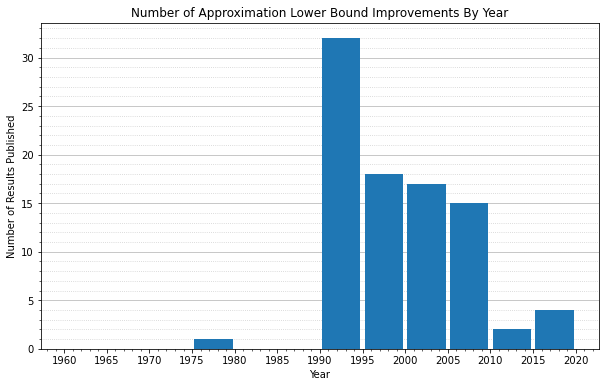

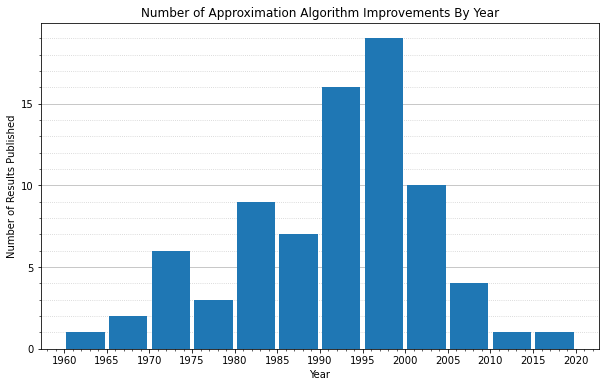

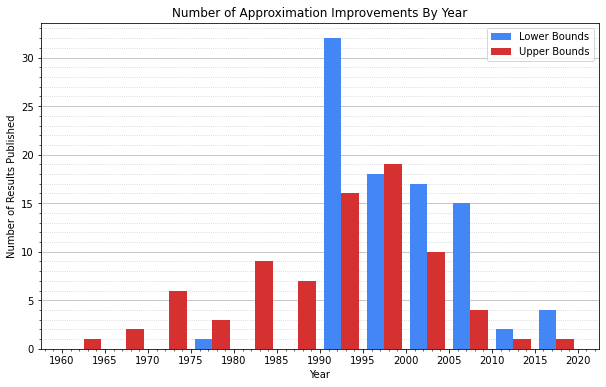

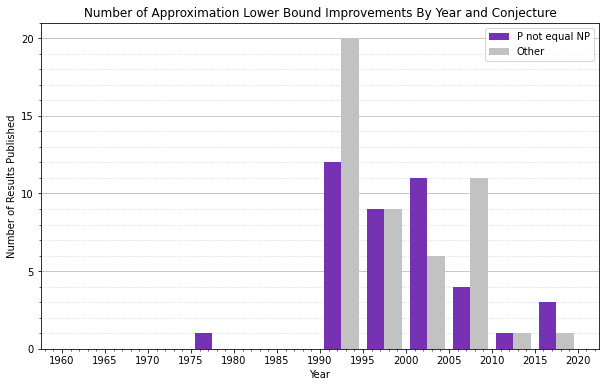

In [31]:
# plot by year
start_year = 1960
end_year = 2025
bin_size = 5
bins = list(range(start_year, end_year, bin_size))


def format_plot(fig, ax):
  ax.set_xticks(np.arange(start_year, end_year, bin_size))
  fig.set_facecolor('white')
  ax.grid(axis='y', zorder=-500, which='major', color='#bbbbbb')
  ax.grid(axis='y', zorder=0, which='minor', color='#cccccc', linestyle=':', linewidth=0.8)
  ax.minorticks_on()
  ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
  ax.yaxis.set_major_locator(ticker.MultipleLocator(5))

# lower bounds

def plot_hist_years(dataset, title):
  fig, ax = plt.subplots()
  fig.set_size_inches(10, 6)

  data = list(dataset["Year"])

  ax.hist(data, bins=bins, rwidth=0.9, zorder=100)
  format_plot(fig, ax)

  ax.set_title(title)
  ax.set_xlabel('Year')
  ax.set_ylabel('Number of Results Published')

  return data


lower_years = plot_hist_years(approximation_lower_bounds, 'Number of Approximation Lower Bound Improvements By Year')
upper_years = plot_hist_years(approximation_algorithms, 'Number of Approximation Algorithm Improvements By Year')

# plot both together
fig, ax = plt.subplots()
labels = ['Lower Bounds', 'Upper Bounds']
colors = ['#4287f5', '#d63131']
fig.set_size_inches(10, 6)
ax.hist([lower_years, upper_years], bins=list(range(start_year, end_year, bin_size)), color=colors, label=labels, zorder=100)
format_plot(fig, ax)
ax.set_title('Number of Approximation Improvements By Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Results Published')
ax.legend(labels)


# separate P neq NP
pnp_results = approximation_lower_bounds[approximation_lower_bounds['Conditional conjecture'] == 'P not equal NP']['Year']
not_pnp_results = approximation_lower_bounds[approximation_lower_bounds['Conditional conjecture'] != 'P not equal NP']['Year']

fig, ax = plt.subplots()
labels = ['P not equal NP', 'Other']
colors = ['#7732b3', '#c2c2c2']
fig.set_size_inches(10, 6)
ax.hist([pnp_results, not_pnp_results], bins=list(range(start_year, end_year, bin_size)), color=colors, label=labels, zorder=100)
format_plot(fig, ax)
ax.set_title('Number of Approximation Lower Bound Improvements By Year and Conjecture')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Results Published')
ax.legend(labels)

In [ ]:




plt.show()

['P not equal NP', 'Unique Games Conjecture, P not equal NP', 'coRP not equal NP', 'NP not a subset of BPP', 'NP not a subset of ZPTIME(2^((log n)^(O(1))))', 'NP not equal ZPP', 'no problem in MaxSNP has a PTAS', 'NEXP not a subset of BPEXP', 'NP not a subset of coRP', '$coR\\tilde{P}\\neq N\\tilde{P}$', 'NP not in $DTIME(2^{poly \\log n})$ (or $\\tilde{P}\\neq N\\tilde{P}$)', 'Other']
[41, 7, 5, 3, 3, 3, 2, 2, 2, 2, 2, 17]


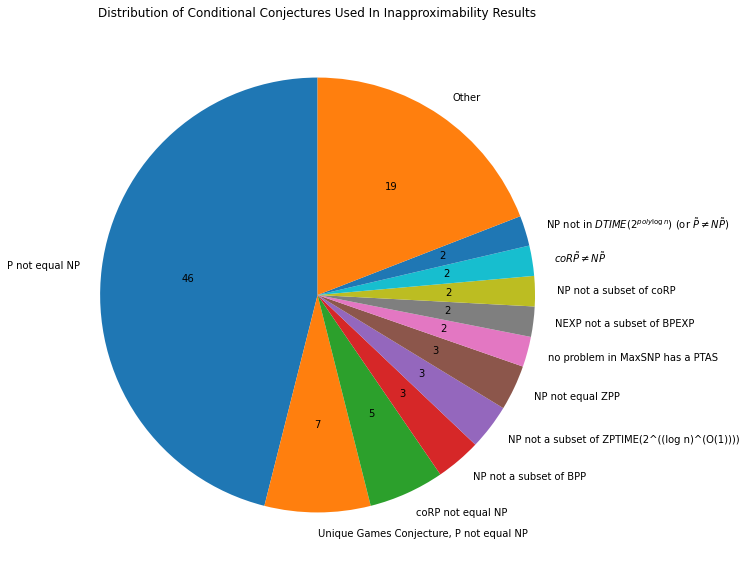

In [8]:
conjectures = {}

for _, row in approximation_lower_bounds.iterrows():
    conj = row['Conditional conjecture']
    conjectures[conj] = conjectures.get(conj, 0) + 1

# lump all the conjectures with 1 lower bound to "other"
other_threshold = 1
conjectures_to_plot = {'Other': 0}

for conj, num in conjectures.items():
    if num <= other_threshold:
        conjectures_to_plot['Other'] += num
    else:
        conjectures_to_plot[conj] = num
    
conjectures
pairs = [(conj, num) for conj, num in conjectures_to_plot.items()]
pairs.sort(key=lambda x: x[1]+(-10000 if x[0]=='Other' else 0), reverse=True)
labels = [x[0] for x in pairs]
sizes = [x[1] for x in pairs]

print(labels)
print(sizes)

fig, ax = plt.subplots()
ax.set_title('Distribution of Conditional Conjectures Used In Inapproximability Results')
fig.set_size_inches(10, 10)
fig.set_facecolor('white')
ax.pie(sizes, labels=labels, autopct='%d', startangle=90)
plt.show()


# todo: by problem
# "strongest" lower bound?
# lump the xTIME() together, potentially

# todo: lump techniques used in the results

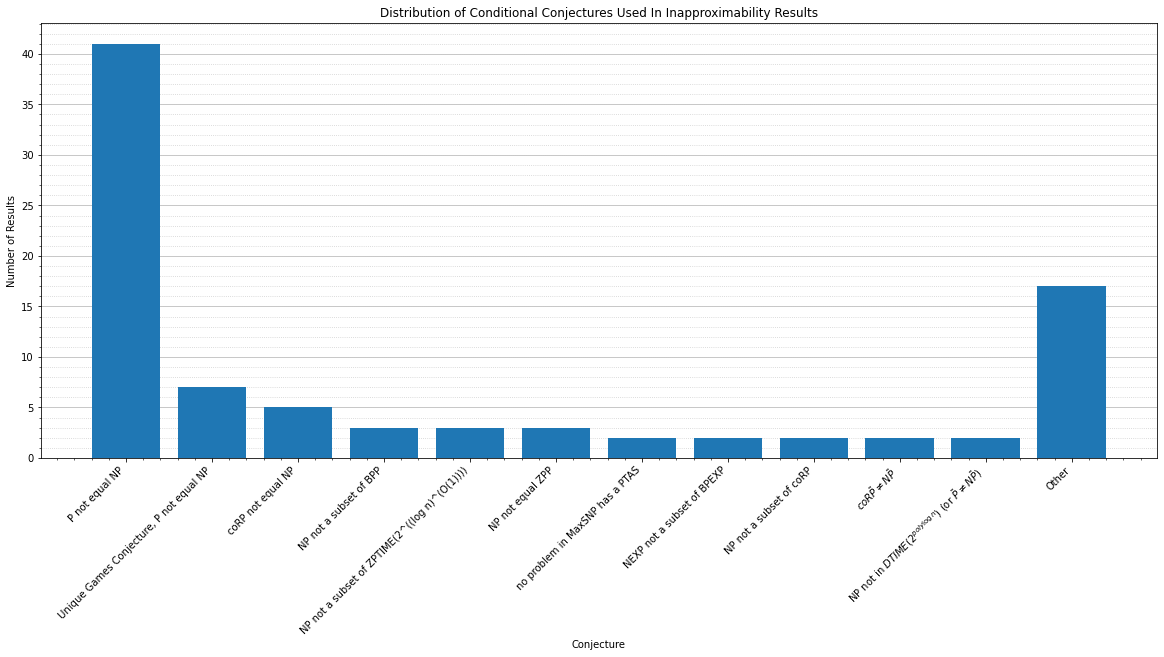

In [9]:
fig, ax = plt.subplots()
ax.set_title('Distribution of Conditional Conjectures Used In Inapproximability Results')
ax.set_xlabel('Conjecture')
ax.set_ylabel('Number of Results')
fig.set_size_inches(20, 8)
fig.set_facecolor('white')
ax.bar(labels, sizes, zorder=100)
ax.grid(axis='y', which='major', color='#bbbbbb')
ax.grid(axis='y', which='minor', color='#cccccc', linestyle=':', linewidth=0.8)
ax.minorticks_on()
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha='right')
plt.show()
conjectures_family_sets: dict[str, set[str]] = {}


{'no problem in MaxSNP has a PTAS': 1,
 'P not equal NP': 13,
 'Unique Games Conjecture, P not equal NP': 5,
 'NP not a subset of BPP': 3,
 'EXP not a subset of NEXP': 1,
 '$\\tilde{P}\\neq N\\tilde{P}$': 1,
 'RP not equal NP': 1,
 'NEXP not a subset of BPEXP': 2,
 'NP not a subset of coRP': 2,
 '$coR\\tilde{P}\\neq N\\tilde{P}$': 2,
 'coRP not equal NP': 2,
 'NP not a subset of DTIME(n^(O(log log n)))': 1,
 'NP not a subset of DTIME(2^((log n)^(O(1))))': 1,
 'NP not equal coR': 1,
 'NP not a subset of ZPTIME(2^((log n)^(O(1))))': 2,
 'NP not equal ZPP': 2,
 'NP not a subset of ZPTIME(2^(O(log n(log log n)^3/2))': 1,
 'NP not a subset of BPTIME(2^((log n)^(O(1))))': 1,
 'NP not in $DTIME(2^{poly \\log n})$ (or $\\tilde{P}\\neq N\\tilde{P}$)': 2,
 "Max 2SAT doesn't have randomized PTAS": 1,
 'NP does not have a quasi-polynomial deterministic time simulation': 1,
 'ETH': 1,
 'NP not in DTIME(n^(log log n))': 1,
 'NP not in QP or DTIME(2^{poly \\log n})$': 1,
 'NP not in ZTIME(2^{poly \\l

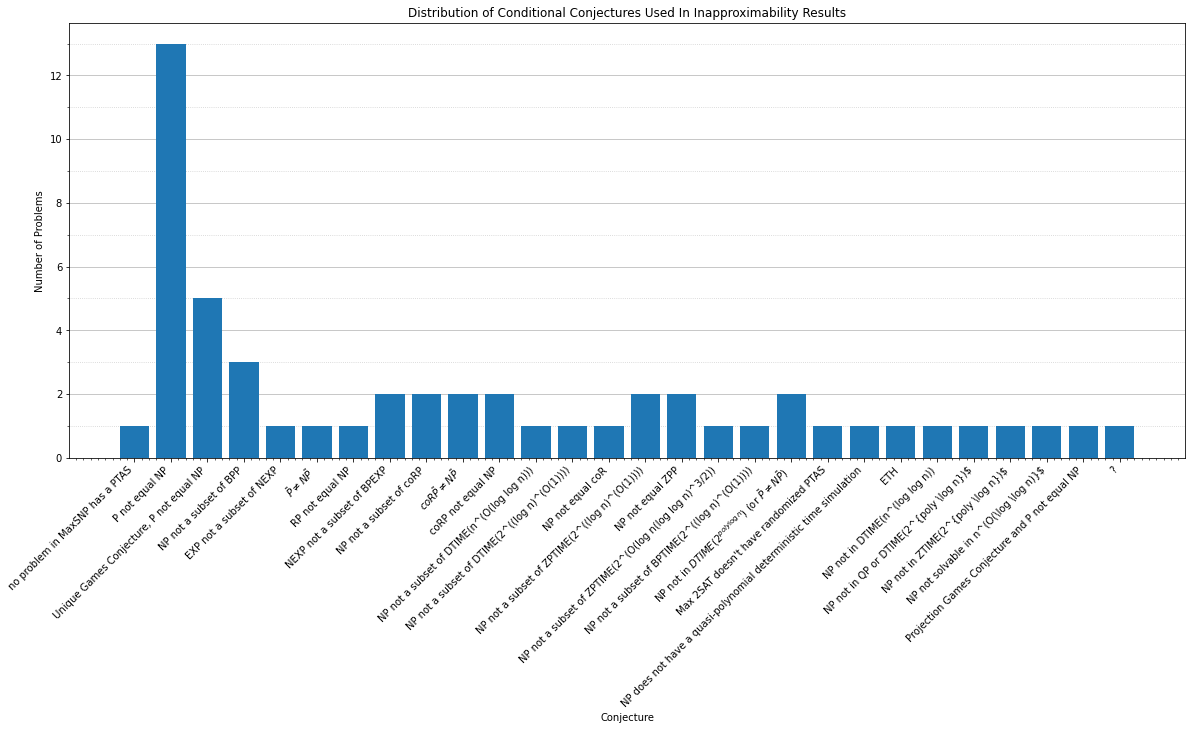

In [ ]:

# group results in the same problem family together as one
for _, row in approximation_lower_bounds.iterrows():
    conj = row['Conditional conjecture']
    conjectures_family_sets.setdefault(conj, set()).add(row['Problem Family'])

conjectures_family_counts = {conj: len(families) for conj, families in conjectures_family_sets.items()}

import pprint
pprint.pp(conjectures_family_counts)

pairs = [(k, v) for k, v in conjectures_family_counts.items()]
labels = [pair[0] for pair in pairs]
sizes = [pair[1] for pair in pairs]

fig, ax = plt.subplots()
ax.set_title('Distribution of Conditional Conjectures Used In Inapproximability Results')
ax.set_xlabel('Conjecture')
ax.set_ylabel('Number of Problems')
fig.set_size_inches(20, 8)
fig.set_facecolor('white')
ax.bar(labels, sizes, zorder=100)
ax.grid(axis='y', which='major', color='#bbbbbb')
ax.grid(axis='y', which='minor', color='#cccccc', linestyle=':', linewidth=0.8)
ax.minorticks_on()
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha='right')
plt.show()


{'Miscellaneous/Unknown': 4,
 'P not equal NP': 42,
 'Unique Games Conjecture, P not equal NP': 7,
 'NP not a subset of BPP': 17,
 'EXP not a subset of NEXP': 1,
 'NEXP not a subset of BPEXP': 2,
 'NP not a subset of DTIME(2^polylog n)': 6,
 'NP not a subset of ZPTIME(2^polylog n)': 5,
 'NP not a subset of BPTIME(2^polylog n)': 1,
 'ETH': 3,
 'Projection Games Conjecture and P not equal NP': 1}


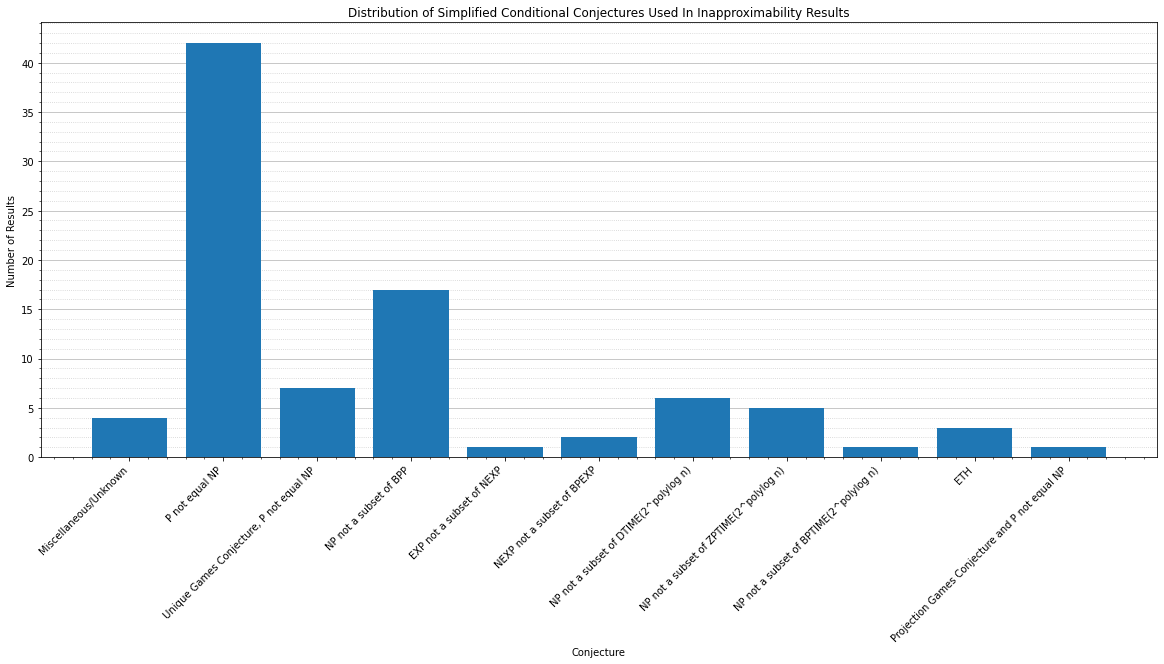

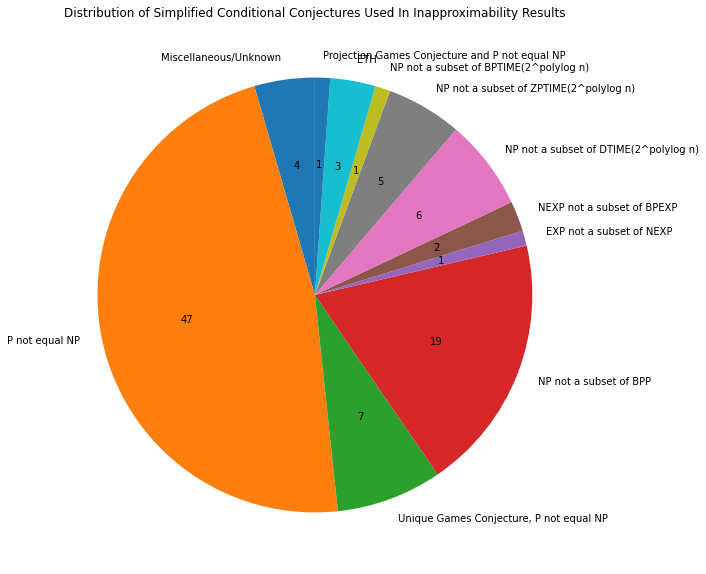

In [ ]:

def simplify_conjecture(conjecture):

    if 'DTIME' in conjecture: 
        return 'NP not a subset of DTIME(2^polylog n)'
    elif 'ZPTIME' in conjecture or 'ZTIME' in conjecture:
        return 'NP not a subset of ZPTIME(2^polylog n)'
    elif 'BPTIME' in conjecture:
        return 'NP not a subset of BPTIME(2^polylog n)'
    elif 'RP' in conjecture or 'ZPP' in conjecture or 'coR' in conjecture: # dumb typo edge case
        return 'NP not a subset of BPP'
    elif 'NP not solvable in' in conjecture:
        return 'ETH'
    elif 'NP does not have a quasi-polynomial' in conjecture:
        return 'ETH' # i think, todo check eth implies this?
    elif conjecture in ['?', 'no problem in MaxSNP has a PTAS', 'Max 2SAT doesn\'t have randomized PTAS']:
        return 'Miscellaneous/Unknown'
    elif '\\neq' in conjecture: # can't find anything different about tilde P
        return 'P not equal NP'
    else:
        return conjecture

conjectures_family_simplify_counts = {}

# group results in the same problem family together as one
for _, row in approximation_lower_bounds.iterrows():
    conj = simplify_conjecture(row['Conditional conjecture'])
    conjectures_family_simplify_counts[conj] = conjectures_family_simplify_counts.get(conj, 0) + 1

pprint.pp(conjectures_family_simplify_counts)

labels = list(conjectures_family_simplify_counts.keys())
sizes = list(conjectures_family_simplify_counts.values())

fig, ax = plt.subplots()
ax.set_title('Distribution of Simplified Conditional Conjectures Used In Inapproximability Results')
ax.set_xlabel('Conjecture')
ax.set_ylabel('Number of Results')
fig.set_size_inches(20, 8)
fig.set_facecolor('white')
ax.bar(labels, sizes, zorder=100)
ax.grid(axis='y', which='major', color='#bbbbbb')
ax.grid(axis='y', which='minor', color='#cccccc', linestyle=':', linewidth=0.8)
ax.minorticks_on()
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha='right')


fig, ax = plt.subplots()
ax.set_title('Distribution of Simplified Conditional Conjectures Used In Inapproximability Results')
fig.set_size_inches(10, 10)
fig.set_facecolor('white')
ax.pie(sizes, labels=labels, autopct='%d', startangle=0)
plt.show()


# todo: by problem

In [32]:
mappings = {
 'Max-2SAT': 'Max-2SAT',
 'Max Weighted 2SAT': 'Max Weighted 2SAT',
 'Max-3SAT': 'Max-3SAT',
 'Max-SAT': 'Max-SAT',
 'Max-Size Clique (Approximate)': 'Max-Size\nClique',
 'Chromatic Number Approximation': 'Chromatic\nNumber',
 'Independent Set (Approximate)': 'Independent Set',
 'Longest Path, Directed (Approximate)': 'Longest Path,\nDirected',
 'Longest Path, Undirected (Approximate)': 'Longest Path,\nGeneral', 
 'Longest Path, General (Approximate)': 'Longest Path,\nGeneral',
 'Maximum Cut, Approximate': 'Maximum Cut',
 'Unweighted Set-Covering': 'Unweighted\nSet-Convering',
 'Unweighted Set-Covering; Weighted Set-Covering': 'Unweighted\nSet-Convering',
 'Approximate Metric TSP': 'Metric TSP',
 'Approximate Symmetric TSP': 'Symmetric TSP',
 'The Vertex Cover Problem, Sparse (Approximate)': 'Vertex Cover,\nSparse',
 'The Vertex Cover Problem, General (Approximate)': 'Vertex Cover,\nGeneral',
 'The Vertex Cover Problem, Unweighted (Approximate)': 'Vertex Cover,\nUnweighted',
 'The Vertex Cover Problem, Unweighted, Dense (Approximate)': 'Vertex Cover\n, Unweighted, Dense',
 'The Vertex Cover Problem, Weighted (Approximate)': 'Vertex Cover\n, Weighted',
 'Minimum Wiener Connector problem': 'Minimum Wiener\nConnector',   
}

problems: tuple[str, str] = []

for _, row in approximation_algorithms.iterrows():
    problems.append((row['Family Name'], row['Variation']))
    
for _, row in approximation_lower_bounds.iterrows():
    problems.append((row['Problem Family'], row['Problem Variation']))
    
set(problems)



{('Boolean 2-Satisfiability', 'Max Weighted 2SAT'),
 ('Boolean 2-Satisfiability', 'Max-2SAT'),
 ('Boolean 3-Satisfiability', 'Max-3SAT'),
 ('Boolean CNF-Satisfiability', 'Max-SAT'),
 ('Clique Problems', 'Max-Size Clique (Approximate)'),
 ('Graph Coloring', 'Chromatic Number Approximation'),
 ('Independent Set', 'Independent Set (Approximate)'),
 ('Longest Path Problem', 'Longest Path, Directed (Approximate)'),
 ('Longest Path Problem', 'Longest Path, General (Approximate)'),
 ('Longest Path Problem', 'Longest Path, Undirected (Approximate)'),
 ('Maximum Cut', 'Maximum Cut, Approximate'),
 ('The Bin Packing Problem',
  'Asymptotic Box Packing Problem Without Rotation'),
 ('The Set-Covering Problem', 'Unweighted Set-Covering'),
 ('The Set-Covering Problem', 'Unweighted Set-Covering, Minimize Overlap'),
 ('The Set-Covering Problem', 'Weighted Set-Covering'),
 ('The Traveling-Salesman Problem', 'Approximate Metric TSP'),
 ('The Traveling-Salesman Problem', 'Approximate Symmetric TSP'),
 ('

In [33]:
# None indicates no shorthand, use original name
short_names = {k: (v if v else k) for k, v in { 
 'Max-2SAT': None,
 'Max Weighted 2SAT': 'Max-2SAT', # temporary hack since we don't have lower bounds yet?
 'Max-3SAT': None,
 'Max-SAT': None,
 'Max-Size Clique (Approximate)': 'Max-Size\nClique',
 'Chromatic Number Approximation': 'Chromatic\nNumber',
 'Independent Set (Approximate)': 'Independent Set',
 'Longest Path, General (Approximate)': 'Longest Path',
 'Maximum Cut, Approximate': 'Maximum Cut',
 'Unweighted Set-Covering': 'Unweighted\nSet-Convering',
 'Approximate Metric TSP': 'Metric TSP',
 'Approximate Symmetric TSP': 'Symmetric TSP',
 'The Vertex Cover Problem, General (Approximate)': 'Vertex Cover',
 'Minimum Wiener Connector problem': 'Minimum Wiener\nConnector',
}.items()}


[{'Max Weighted 2SAT', 'Max-2SAT'},
 {'Max-3SAT'},
 {'Max-SAT'},
 {'Max-Size Clique (Approximate)'},
 {'Chromatic Number Approximation'},
 {'Independent Set (Approximate)'},
 {'Longest Path, General (Approximate)'},
 {'Maximum Cut, Approximate'},
 {'Unweighted Set-Covering',
  'Unweighted Set-Covering, Minimize Overlap',
  'Unweighted Set-Covering; Weighted Set-Covering',
  'Weighted Set-Covering'},
 {'Approximate Metric TSP'},
 {'The Vertex Cover Problem, General (Approximate)',
  'The Vertex Cover Problem, Unweighted (Approximate)',
  'The Vertex Cover Problem, Unweighted, Dense (Approximate)',
  'The Vertex Cover Problem, Weighted (Approximate)'},
 {'Minimum Wiener Connector problem'}]


from pprint import pp

"""
 'Boolean 2-Satisfiability': '2-SAT', 
 'Boolean 3-Satisfiability': '3-SAT',
 'Boolean CNF-Satisfiability': 'CNF-SAT',
 'Clique Problems': None,
 'Graph Coloring': None,
 'Independent Set': None,
 'Longest Path Problem': 'Longest Path',
 'Maximum Cut': None,
 'The Set-Covering Problem': 'Set Covering',
 'The Traveling-Salesman Problem': 'Traveling Salesman',
 'The Vertex Cover Problem': 'Vertex Cover',
 'Wiener Index': None
"""


pp([a for d in [{'Max-2SAT'},
 {'Max-3SAT'},
 {'Max-SAT'},
 {'Max-Size Clique (Approximate)'},
 {'Chromatic Number Approximation'},
 {'Independent Set (Approximate)'},
 {'Longest Path, Directed (Approximate)',
  'Longest Path, Undirected (Approximate)'},
 {'Maximum Cut, Approximate'},
 {'Unweighted Set-Covering'},
 {'Approximate Metric TSP', 'Approximate Symmetric TSP'},
 {'The Vertex Cover Problem, General (Approximate)',
  'The Vertex Cover Problem, Sparse (Approximate)'},
 {'Minimum Wiener Connector problem'}] for a in d ])


print(short_names)

approximation_by_family_best = approximation_algorithms.groupby("Family Name").agg(
    {"Variation": list}
).reset_index()

inapprox_by_family_best = approximation_lower_bounds.groupby("Problem Family").agg(
    {"Problem Variation": list}
).reset_index()

pp(approximation_by_family_best)


['Max-2SAT',
 'Max-3SAT',
 'Max-SAT',
 'Max-Size Clique (Approximate)',
 'Chromatic Number Approximation',
 'Independent Set (Approximate)',
 'Longest Path, Undirected (Approximate)',
 'Longest Path, Directed (Approximate)',
 'Maximum Cut, Approximate',
 'Unweighted Set-Covering',
 'Approximate Metric TSP',
 'Approximate Symmetric TSP',
 'The Vertex Cover Problem, Sparse (Approximate)',
 'The Vertex Cover Problem, General (Approximate)',
 'Minimum Wiener Connector problem']
{'Max-2SAT': 'Max-2SAT', 'Max Weighted 2SAT': 'Max-2SAT', 'Max-3SAT': 'Max-3SAT', 'Max-SAT': 'Max-SAT', 'Max-Size Clique (Approximate)': 'Max-Size\nClique', 'Chromatic Number Approximation': 'Chromatic\nNumber', 'Independent Set (Approximate)': 'Independent Set', 'Longest Path, General (Approximate)': 'Longest Path', 'Maximum Cut, Approximate': 'Maximum Cut', 'Unweighted Set-Covering': 'Unweighted\nSet-Convering', 'Approximate Metric TSP': 'Metric TSP', 'Approximate Symmetric TSP': 'Symmetric TSP', 'The Vertex Cover

{'Max-2SAT': 2.064,
 'Max-3SAT': 2.143,
 'Max-SAT': 2.0,
 'Max-Size\nClique': 8.96,
 'Chromatic\nNumber': 8.96,
 'Independent Set': 8.98,
 None: 8.98,
 'Maximum Cut': 2.138,
 'Unweighted\nSet-Convering': 6.0,
 'Metric TSP': 2.0002,
 'Symmetric TSP': 2.008,
 'Vertex Cover': 2.99,
 'Minimum Wiener\nConnector': 2.0}
{'Chromatic\nNumber': 8.98,
 'Metric TSP': 2.499,
 None: 2.99,
 'Vertex Cover': 2.99,
 'Longest Path': 8.99,
 'Unweighted\nSet-Convering': 6.0,
 'Maximum Cut': 2.239,
 'Minimum Wiener\nConnector': 2.0,
 'Independent Set': 8.98,
 'Max-2SAT': 2.064,
 'Max-3SAT': 2.143,
 'Max-SAT': 2.5,
 'Max-Size\nClique': 8.98}
{'Max-2SAT': 2.064, 'Max-3SAT': 2.143, 'Independent Set': 8.98, 'Unweighted\nSet-Convering': 6.0, 'Vertex Cover': 2.99, 'Minimum Wiener\nConnector': 2.0}


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_50768/782395264.py:67: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


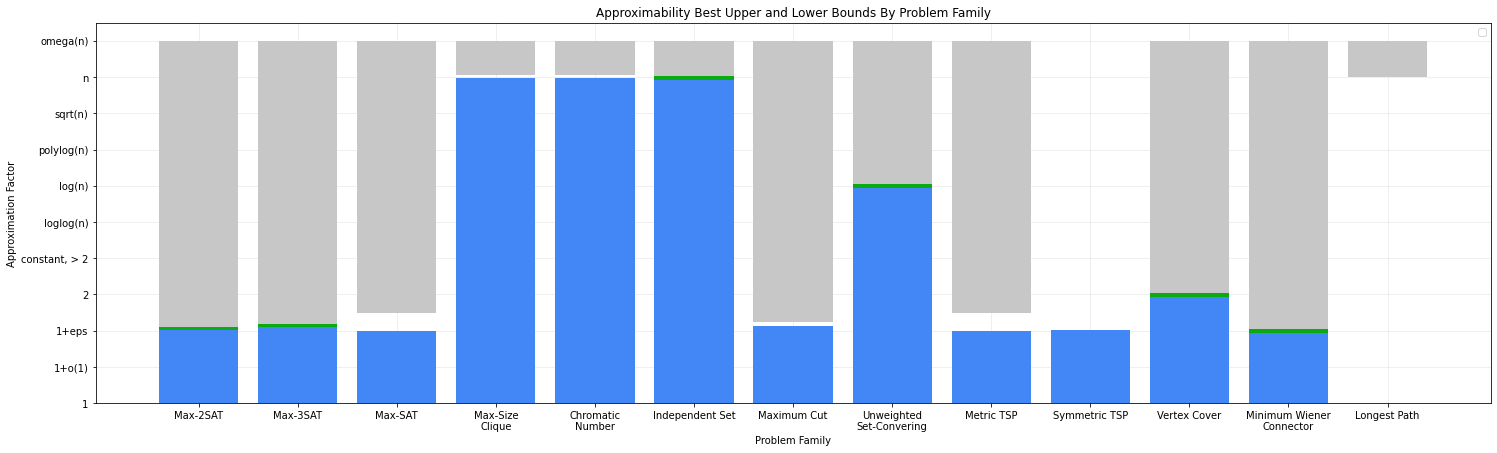

In [34]:


fig, ax = plt.subplots()
fig.set_size_inches(25, 7)
fig.set_facecolor('white')

def filter_data(families, apx):
    return tuple(zip(*[(f, a) for f, a in zip(families, apx, strict=True) if f in short_names.values()]))

plot_families_lower = list(approximation_lower_bounds["Problem Variation"].map(lambda name: short_names.get(name, None)))
plot_apx_lower = list(approximation_lower_bounds["Approximation Factor Class (Mult)"])

plot_families_upper = list(approximation_algorithms["Variation"].map(lambda name: short_names.get(name, None)))
plot_apx_upper = list(approximation_algorithms["Approximation Factor Class (Mult)"])

top_edge = 10

best_lower = {}
for family, lower_bound in zip(plot_families_lower, plot_apx_lower):
    if family not in best_lower:
        best_lower[family] = lower_bound
    else:
        best_lower[family] = max(best_lower[family], lower_bound)
best_upper = {}
for family, upper_bound in zip(plot_families_upper, plot_apx_upper):
    if family not in best_upper:
        best_upper[family] = upper_bound
    else:
        best_upper[family] = min(best_upper[family], upper_bound)

pp(best_lower)
pp(best_upper)

tight_families = {}
for family in best_lower:
    if family in best_upper and best_lower[family] == best_upper[family]:
        tight_families[family] = best_lower[family]
    
print(tight_families)

plot_families_lower, plot_apx_lower = filter_data(list(plot_families_lower), list(plot_apx_lower))
plot_families_upper, plot_apx_upper = filter_data(list(plot_families_upper), list(plot_apx_upper))

# artifically increase distance for non tight bounds
spacing_amount = 0.1
plot_apx_upper = [apx if family in tight_families else max(apx, best_lower.get(family, 0)+spacing_amount) 
                  for family, apx in zip(plot_families_upper, plot_apx_upper) ]
upper_lengths = [top_edge - x for x in plot_apx_upper]


ax.bar(plot_families_lower, plot_apx_lower, zorder=100, color='#4287f5')
ax.bar(plot_families_upper, upper_lengths, zorder=100, color='#c7c7c7', bottom=plot_apx_upper)

# green lines for tight bounds
line_thickness = 0.1
ax.bar(tight_families.keys(), line_thickness, zorder=1000, color='#09ab13', bottom=[x-line_thickness/2 for x in tight_families.values()] )

ax.set_xlabel('Problem Family')
ax.set_ylabel('Approximation Factor')
ax.set_title('Approximability Best Upper and Lower Bounds By Problem Family')
ax.legend(loc="upper right")

# stylistic stuff, labels, formatting, etc.
approx_classes = ['1', '1+o(1)', '1+eps', '2', 'constant, > 2', 'loglog(n)', 'log(n)', 'polylog(n)', 'sqrt(n)', 'n', 'omega(n)']
plt.yticks(np.arange(0, 11, 1), approx_classes)
ax.grid(True, alpha=0.25, zorder=0)


fig.show()

In [35]:
# unique games vs P neq NP

def fill_best_algo(df, column="Approximation Factor Class (Mult)"):
    best = []
    last_best = 99999
    for index, row in df.iterrows():
        if row[column] < last_best:
            best.append(True)
            last_best = row[column]
        else:
            best.append(False)

    return best
    
def fill_best_lb(df, column="Approximation Factor Class (Mult)"):
    best = []
    last_best = 0
    for index, row in df.iterrows():
        if row[column] > last_best:
            best.append(True)
            last_best = row[column]
        else:
            best.append(False)

    return best


def plot_family_all(family):
    
    df1 = approximation_algorithms.copy()
    df2 = approximation_lower_bounds.copy()

    df1 = df1[df1['Family Name'] == family]
    df2 = df2[df2['Problem Family'] == family]


    # Reduce opcity of point that are not the best
    
    df1['Best'] = fill_best_algo(df1)
    df2['Best'] = fill_best_lb(df2)

    plt.figure(figsize=(6, 6))
    # hide in legend
    plt.scatter(df1['Year'], df1['Approximation Factor Class (Mult)']+1, color='#DD444422')
    plt.scatter(df2['Year'], df2['Approximation Factor Class (Mult)']+1, color='#5975A422')

    if len(df1) > 0:
        best_approximate = df1[df1['Best']]
        last_row = best_approximate.iloc[-1:].copy()
        last_row['Year'] = 2024
        best_approximate = pd.concat([best_approximate, last_row], ignore_index=True)
        plt.scatter(best_approximate['Year'], best_approximate['Approximation Factor Class (Mult)']+1, label='approx algo', color='#DD4444')
        plt.step(best_approximate['Year'], best_approximate['Approximation Factor Class (Mult)']+1, where='post', color='#DD4444')

    if len(df2) > 0:
        best_lb = df2[df2['Best']]
        last_row2 = best_lb.iloc[-1:].copy()
        last_row2['Year'] = 2024
        best_lb = pd.concat([best_lb, last_row2], ignore_index=True)
        plt.scatter(best_lb['Year'], best_lb['Approximation Factor Class (Mult)']+1, label='lower bound', color='#5975A4')
        plt.step(best_lb['Year'], best_lb['Approximation Factor Class (Mult)']+1, where='post', color='#5975A4')
        
    current_best_lb = best_lb['Approximation Factor Class (Mult)'].iloc[-1]
    current_best_approx = best_approximate['Approximation Factor Class (Mult)'].iloc[-1]
    if current_best_lb == current_best_approx:
        matching_year = min(best_lb['Year'].iloc[-2], best_approximate['Year'].iloc[-1])
        plt.scatter([2024], [current_best_lb+1], color='green')
        plt.step([matching_year, 2024], [current_best_lb+1]*2, where='post', color='green')
        #plt.figtext(0.8, (current_best_lb+1.3)/12, str(best_lb['Exact Inapprox. Ratio'].iloc[-1]), ha='center', fontsize=10)
        


    plt.yticks(np.arange(1, 12, 1), ['1', '1+o(1)', '1+eps', '2', 'constant, > 2', 'loglog(n)', 'log(n)', 'polylog(n)', 'sqrt(n)', 'n', 'omega(n)'])


    plt.xlabel('Year')
    plt.ylabel('Approx Class')
    plt.legend()
    plt.title(family)
    
    plt.savefig('figures/prog-all/'+family+'.png', bbox_inches='tight')
    
    plt.show()



ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

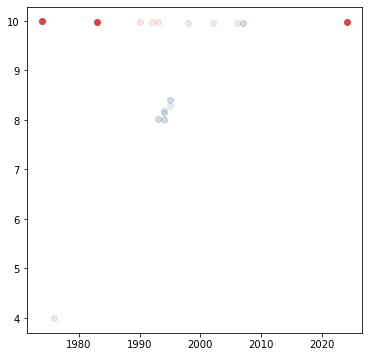

In [23]:
for family in approximation_algorithms['Family Name'].unique():
    plot_family_all(family)

In [36]:
def plot_family_cst(family):
    
    df1 = approximation_algorithms.copy()
    df2 = approximation_lower_bounds.copy()

    df1 = df1[df1['Family Name'] == family]
    df1 = df1[df1['Approximation Factor Class (Mult)'] <= 4.5]
    df2 = df2[df2['Problem Family'] == family]
    df2 = df2[df2['Approximation Factor Class (Mult)'] <= 4.5]
    
    if df1.size > 0:
    
        df1['Best'] = fill_best_algo(df1)
        df2['Best'] = fill_best_lb(df2)

        plt.figure(figsize=(6, 6))
        plt.scatter(df1['Year'], df1['Approximation Factor Class (Mult)']+1, color='#DD444422')
        plt.scatter(df2['Year'], df2['Approximation Factor Class (Mult)']+1, color='#5975A422')

        if len(df1) > 0:
            best_approximate = df1[df1['Best']]
            last_row = best_approximate.iloc[-1:].copy()
            last_row['Year'] = 2024
            best_approximate = pd.concat([best_approximate, last_row], ignore_index=True)
            plt.scatter(best_approximate['Year'], best_approximate['Approximation Factor Class (Mult)']+1, label='approx algo', color='#DD4444')
            plt.step(best_approximate['Year'], best_approximate['Approximation Factor Class (Mult)']+1, where='post', color='#DD4444')

        if len(df2) > 0:
            best_lb = df2[df2['Best']]
            last_row2 = best_lb.iloc[-1:].copy()
            last_row2['Year'] = 2024
            best_lb = pd.concat([best_lb, last_row2], ignore_index=True)
            plt.scatter(best_lb['Year'], best_lb['Approximation Factor Class (Mult)']+1, label='lower bound', color='#5975A4')
            plt.step(best_lb['Year'], best_lb['Approximation Factor Class (Mult)']+1, where='post', color='#5975A4')
        

        current_best_lb = best_lb['Approximation Factor Class (Mult)'].iloc[-1]
        current_best_approx = best_approximate['Approximation Factor Class (Mult)'].iloc[-1]
        if current_best_lb == current_best_approx:
            matching_year = min(best_lb['Year'].iloc[-2], best_approximate['Year'].iloc[-1])
            plt.scatter([2024], [current_best_lb+1], color='green')
            plt.step([matching_year, 2024], [current_best_lb+1]*2, where='post', color='green')

        plt.yticks(np.arange(1, 6, 1), ['1', '1+o(1)', '1+eps', '2', 'constant, > 2'])


        plt.xlabel('Year')
        plt.ylabel('Approx Class')
        plt.legend()
        plt.title(family + " (cst factor)")
        
        plt.savefig('figures/prog-cst/'+family+'.png', bbox_inches='tight')
        
        plt.show()


ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

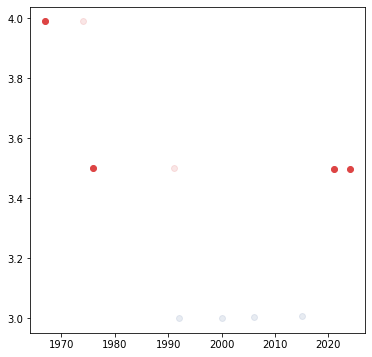

In [37]:
for family in approximation_algorithms['Family Name'].unique():
    plot_family_cst(family)

In [ ]:
#approximation_algorithms['Approximation Factor Class (Mult)'].tolist()

In [38]:
def plot_family_runtime_vs_approx(family):
    
    df1 = approximation_algorithms.copy()
    df2 = approximation_lower_bounds.copy()

    df1 = df1[df1['Family Name'] == family]
    df2 = df2[df2['Problem Family'] == family]

    
    df1.sort_values(by=['Approximation Factor Class (Mult)', 'Time Complexity Class'], ascending=[True, False], inplace=True)
    df2.sort_values(by=['Approximation Factor Class (Mult)'], inplace=True)
    
    trivial_algo = 9
    if family == 'The Traveling-Salesman Problem':
        trivial_algo = 10
    
    algos_x = df1['Approximation Factor Class (Mult)'].tolist()+[trivial_algo]
    algos_y = df1['Time Complexity Class'].tolist()+[3]
    
    inapprox_x = df2['Approximation Factor Class (Mult)'].tolist()
    inapprox_y = [7]*df2.shape[0]
    
    for i in range(len(algos_x)):
        algos_x[i] += 1
    
    for i in range(len(inapprox_x)):
        inapprox_x[i] += 1

    # Reduce opcity of point that are not the best
    
    best_algos_x = []
    best_algos_y = []
    best_algo_runtime = 999
    for i in range(len(algos_x)):
        if algos_y[i] < best_algo_runtime:
            if len(best_algos_x) > 0 and algos_x[i] == best_algos_x[-1]:
                best_algos_y[-1] = algos_y[i]
            else:
                best_algos_x.append(algos_x[i])
                best_algos_y.append(algos_y[i])
            best_algo_runtime = algos_y[i]
    
    best_inapprox_x = []
    best_inapprox_y = []
    best_inapprox_runtime = 999
    for i in range(len(inapprox_x)-1, -1, -1):
        if inapprox_y[i] < best_inapprox_runtime:
            if len(best_inapprox_x) > 0 and inapprox_x[i] == best_inapprox_x[-1]:
                best_inapprox_x[-1] = inapprox_x[i]
            else:
                best_inapprox_x.insert(0, inapprox_x[i])
                best_inapprox_y.insert(0, inapprox_y[i])
            best_inapprox_runtime = inapprox_y[i]
    
    #df1['Best'] = fill_best_algo(df1)
    #df2['Best'] = fill_best_lb(df2)

    plt.figure(figsize=(9, 6))
    # hide in legend
    plt.scatter(algos_x, algos_y, color='#DD444412')
    plt.scatter(inapprox_x, inapprox_y, color='#5975A412')
    
    plt.scatter(best_algos_x, best_algos_y, label='approx algo', color='#DD4444')
    plt.scatter(best_inapprox_x, best_inapprox_y, label='inapprox', color='#5975A4')
    plt.scatter([1], [9], color='#9B5D74')
    
    best_algos_x = [1]+best_algos_x+[11.5]
    best_algos_y = [9]+best_algos_y+best_algos_y[-1:]
    
    best_inapprox_x = [1]+best_inapprox_x+[11.5]
    best_inapprox_y = [9]+best_inapprox_y+[1]#best_inapprox_y[0:1]+best_inapprox_y+[1]
    
    plt.step(best_algos_x, best_algos_y, where='post', color='#DD4444')
    plt.step(best_inapprox_x, best_inapprox_y, where='pre', color='#5975A4')
    
    plt.fill_between(best_algos_x, best_algos_y, 9.5, step='post', facecolor='#DD444450')
    plt.fill_between(best_inapprox_x, 1, best_inapprox_y, step='pre', facecolor='#5975A450')
        


    plt.xticks(np.arange(1, 12, 1), ['$1$', '$1+o(1)$', '$1+\epsilon$', '$2$', '$C_{>2}$', '$\log\log(n)$', '$\log(n)$', '$poly\log(n)$', '$\sqrt{n}$', '$n$', '$\omega(n)$'])
    plt.yticks(np.arange(1, 10, 1), ['Constant', 'Polylogarithmic', 'Linear', 'Quasilinear', 'Quadratic', 'Cubic', 'Polynomial ($n^{O(1)}$)', 'Quasipolynomial', 'Exponential'])


    plt.xlabel('Approx Class')
    plt.ylabel('Time Complexity')
    plt.legend()
    plt.title(family)
    
    plt.savefig('figures/time-vs-approx/'+family+'.png', bbox_inches='tight')
    
    plt.show()



In [ ]:
for family in approximation_algorithms['Family Name'].unique():
    plot_family_runtime_vs_approx(family)